# Trabalho Prático 2 — Ciência de Dados
## Inflação sobre bens de consumo: Brasil e o mundo

### Objetivo

Este notebook inicia uma análise da evolução da inflação sobre bens de consumo ao consumidor, com seções que focam na comparação do Brasil com outros países e regiões do mundo.

Dataset utilizado disponível em:

*Observação: o indicador mede a variação percentual anual dos preços ao consumidor. Portanto, ele representa uma **taxa de inflação**, e não o nível absoluto de preços nem o custo de uma cesta específica de bens.

## 1. Bibliotecas

In [194]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from io import StringIO
from scipy import stats
from IPython.display import display

## 2. Carregamento dos dados

O CSV do World Bank possui linhas introdutórias antes do cabeçalho. Por isso, neste arquivo, "skiprows=4" é utilizado no dataset principal. Os metadados não precisam receber o mesmo tratamento.

In [195]:
with open("./API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_368812.csv", "r", encoding="utf-8-sig") as file:
    inflation_csv = file.read()

with open("./Metadata_Country_API_FP.CPI.TOTL.ZG_DS2_en_csv_v2_368812.csv", "r", encoding="utf-8-sig") as file:
    metadata_csv = file.read()

inflation_df = pd.read_csv(StringIO(inflation_csv), skiprows=4)
country_meta = pd.read_csv(StringIO(metadata_csv))

print("Dataset principal:", inflation_df.shape)
print("Metadata:", country_meta.shape)

Dataset principal: (265, 71)
Metadata: (264, 6)


## 3. Estrutura inicial

O dataset principal apresenta os anos como colunas, isto é, está no formato **wide**. As colunas de identificação são `Country Name`, `Country Code`, `Indicator Name` e `Indicator Code`.

Os anos de 1960 a 2025 serão identificados automaticamente para evitar depender de uma lista digitada manualmente.

In [196]:
year_columns = [c for c in inflation_df.columns if str(c).isdigit()]

print("Primeiro ano:", year_columns[0])
print("Último ano:", year_columns[-1])
print("Quantidade de anos:", len(year_columns))

display(inflation_df.head())

Primeiro ano: 1960
Último ano: 2025
Quantidade de anos: 66


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.03,3.63,4.26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,6.22,4.69,4.10,5.19,6.82,10.88,7.40,4.77,4.27,NaN
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,4.98,0.63,2.30,5.60,5.13,13.71,-4.64,-6.60,NaN,NaN
3,Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,1.73,1.78,1.98,2.49,3.75,7.95,5.22,3.61,1.66,NaN
4,Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,...,29.84,19.63,17.08,22.27,25.75,21.36,13.64,28.24,20.16,NaN


### 4. Classificação entre País ou região

Como não existem somente países no dataset, pode ser útil separar regiões agregadas para não afetar cálculos de média, por exemplo

In [197]:
def classificar(row):
    if pd.isna(row["Region"]):
        return "Aggregated"
    else:
        return "Country"

## 5. Normalização dos tipos

As colunas anuais serão convertidas para valores numéricos. Valores vazios do CSV são transformados em `NaN`, permitindo que o Pandas os reconheça como dados ausentes.

Não será feita imputação nesta etapa. Primeiro é necessário medir a cobertura dos dados para decidir quais anos e quais entidades podem sustentar a análise.

In [198]:
country_meta["Type"] = country_meta.apply(classificar, axis=1)

inflation_df = inflation_df.merge(
    country_meta[["Country Code", "Region", "IncomeGroup", "Type"]],
    on="Country Code", how="left"
)

inflation_df = inflation_df.drop(columns=["Indicator Name", "Indicator Code", "Unnamed: 70"],
                                 errors="ignore")

year_columns = [col for col in inflation_df.columns if col.isdigit()]
inflation_df[year_columns] = inflation_df[year_columns].apply(pd.to_numeric, errors="coerce")

#Separação entre países e agregados
countries_df = inflation_df[inflation_df["Type"] == "Country"]
aggregates_df = inflation_df[inflation_df["Type"] == "Aggregated"]

print("Quantidade total de valores ausentes:")
print(inflation_df[year_columns].isna().sum().sum())

display(inflation_df[["Country Name", "Country Code"] + year_columns[:5]].head())

Quantidade total de valores ausentes:
6018


,Country Name,Country Code,1960,1961,1962,1963,1964
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN


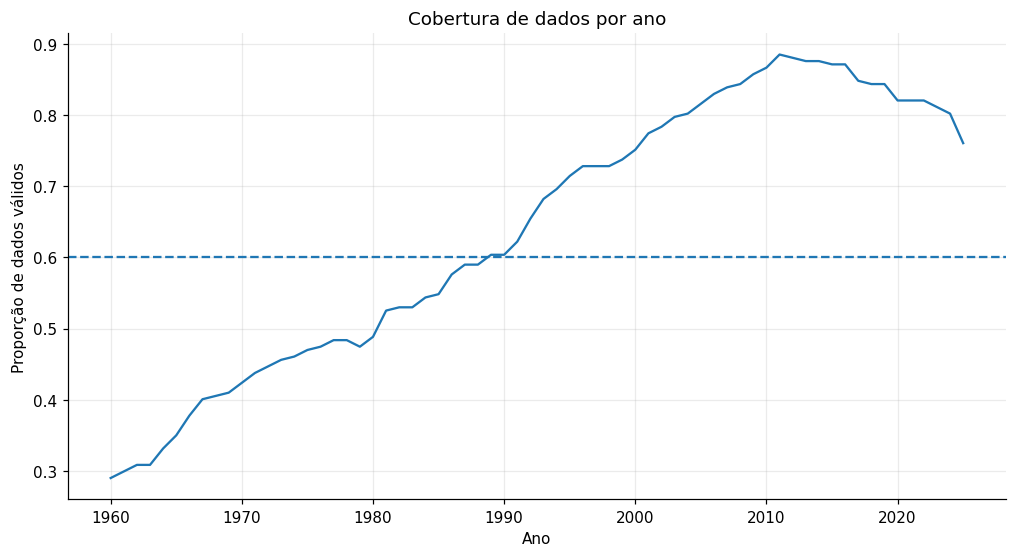

In [199]:
# Definir mínimo de dados para ser considerado válido
# Anos com pelo menos 60% de dados válidos
coverage = countries_df[year_columns].notna().mean()
valid_years = list(coverage[coverage >= 0.60].index)

coverage.plot()

plt.axhline(0.60, linestyle='--')
plt.title("Cobertura de dados por ano")
plt.ylabel("Proporção de dados válidos")
plt.xlabel("Ano")

plt.show()

In [ ]:
country_meta["Type"] = np.where(
    country_meta["Region"].notna(),
    "Country",
    "Aggregated"
)

metadata_columns = [
    "Country Code",
    "Region",
    "IncomeGroup",
    "Type"
]

id_columns = ["Country Name", "Country Code", "Region", "IncomeGroup"]

#Transformando o dataset do formato wide para long
inflation_raw_long = countries_df[id_columns + valid_years].melt(
    id_vars=id_columns,
    value_vars=valid_years,
    var_name="Year",
    value_name="Inflation Rate"
)
inflation_raw_long["Year"] = inflation_raw_long["Year"].astype(int)
inflation_raw_long = inflation_raw_long.sort_values(["Country Code", "Year"])

# Versão preenchida (interpolação + média do país)
inflation_df_long = inflation_raw_long.copy()
inflation_df_long["Inflation Rate"] = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform(
    lambda x: x.interpolate(method="linear", limit=3, limit_direction="both")
)

#Substituição pela média do país caso ainda haja lacunas:
country_mean = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform("mean")
inflation_df_long["Inflation Rate"] = inflation_df_long["Inflation Rate"].fillna(country_mean)

# Drop, caso ainda haja lacunas:
inflation_df_long = inflation_df_long.dropna(subset=["Inflation Rate"])

inflation_raw_long = inflation_raw_long.dropna(subset=["Inflation Rate"])

print("Anos válidos:", valid_years[0], "a", valid_years[-1])
print("Observações sem preenchimento:", len(inflation_raw_long))
print("Observações com preenchimento:", len(inflation_df_long))
display(inflation_raw_long.groupby("Region")["Inflation Rate"].describe())

Anos válidos: 1989 a 2025
Observações sem preenchimento: 6311
Observações com preenchimento: 7141


,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
East Asia & Pacific,962.00,5.32,11.95,-4.01,1.36,3.13,6.18,268.15
Europe & Central Asia,"1,632.00",29.08,198.35,-10.63,1.66,3.15,7.71,"4,734.91"
Latin America & Caribbean,"1,159.00",27.12,274.55,-7.11,2.06,4.26,8.30,"7,481.66"
Middle East & North Africa,741.00,8.96,27.83,-16.12,1.59,3.48,8.25,448.50
North America,73.00,2.52,1.46,-0.36,1.62,2.26,2.95,8.00
South Asia,222.00,6.87,5.02,-4.76,3.84,6.28,8.91,49.72
Sub-Saharan Africa,"1,522.00",40.55,637.45,-16.86,2.52,5.93,11.40,"23,773.13"


## Atenção:

O preenchimento pela média do país distorce rankings quando faltam muitos anos seguidos.
A República Democrática do Congo não tem dados de 2017 a 2025 e, como sua média histórica é
puxada pela hiperinflação de 1994, o preenchimento atribui a ela mais de 1000% de inflação em
todos esses anos — o que a colocaria falsamente como o país mais inflacionário de 2025.

Por isso, os rankings e máximos desta seção usam o `inflation_raw_long` (somente valores
observados), enquanto médias e medianas agregadas podem usar o `inflation_df_long`.

In [210]:
congo_raw = inflation_raw_long[inflation_raw_long["Country Code"] == "COD"]
congo_filled = inflation_df_long[inflation_df_long["Country Code"] == "COD"]

print("Último ano observado para o Congo:", congo_raw["Year"].max())
print("Valor preenchido em 2025:")
display(congo_filled[congo_filled["Year"] == 2025][["Country Name", "Year", "Inflation Rate"]])

Último ano observado para o Congo: 2016
Valor preenchido em 2025:


,Country Name,Year,Inflation Rate
7851,"Congo, Dem. Rep.",2025,"1,123.10"


## Quais países tiveram o aumento mais brusco de inflação (Maior pico)?

Como a inflação varia de valores negativos a mais de 20000%, os gráficos comparativos usam
escala logarítmica. Em escala linear, um único episódio de hiperinflação achata todo o resto.

In [ ]:
# Ano de pico de cada país
peak_index = inflation_raw_long.groupby("Country Name")["Inflation Rate"].idxmax()
peaks = inflation_raw_long.loc[peak_index]

top_peaks = peaks.nlargest(15, "Inflation Rate").sort_values("Inflation Rate")

plt.figure(figsize=(9, 6))
plt.barh(top_peaks["Country Name"], top_peaks["Inflation Rate"])
plt.xscale("log")
plt.title("15 Maiores Picos Anuais de Inflação")
plt.xlabel("Inflação no ano de pico (%) - escala log")
plt.ylabel("País")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

display(top_peaks.sort_values("Inflation Rate", ascending=False)[["Country Name", "Year", "Inflation Rate"]])

## É importante notar que:

Os picos se concentram em duas janelas históricas: a transição pós-socialista (Ucrânia,
Armênia, Bielorrússia, Cazaquistão, Azerbaijão, entre 1993 e 1994) e as crises
latino-americanas do fim dos anos 1980 (Peru, Brasil, Argentina). O maior valor da base é o da
República Democrática do Congo em 1994, com 23773%.

O Brasil aparece em 6º lugar, com 2948% em 1990 — o ápice do ciclo que antecedeu o Plano Real.
Nenhum pico dessa magnitude ocorre depois de 1997 na base.

2.3 Inflação elevada não é o mesmo que inflação brusca

O gráfico anterior mede a intensidade do pior ano. Este mede persistência: em quantos anos o
país teve inflação de dois dígitos.

In [ ]:
high_inflation = inflation_raw_long[inflation_raw_long["Inflation Rate"] >= 10]

years_high = high_inflation.groupby("Country Name").size()
years_observed = inflation_raw_long.groupby("Country Name").size()

top_persistent = years_high.nlargest(15).sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_persistent.index, top_persistent.values)
plt.title("Países com Mais Anos de Inflação Acima de 10%")
plt.xlabel("Número de anos")
plt.ylabel("País")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

print("Brasil:", years_high["Brazil"], "anos com inflação >= 10%,",
      "em", years_observed["Brazil"], "anos observados")
print("Anos em que o Brasil teve inflação >= 10%:")
print(sorted(high_inflation[high_inflation["Country Name"] == "Brazil"]["Year"].tolist()))

## 9. Cobertura dos dados por ano

Antes de escolher o período de análise, será calculada a proporção de países com valores válidos em cada ano.

Esse diagnóstico permitirá definir um critério objetivo para o período analisado, em vez de escolher arbitrariamente um ano inicial. A imputação de valores faltantes será tratada somente depois dessa decisão.

In [202]:
coverage = inflation_countries[year_columns].notna().mean()
valid_years = list(coverage[coverage >= 0.60].index)
ID_COLS = ["Country Name", "Country Code", "Region", "IncomeGroup"]

inflation_long_raw = (
    inflation_countries[ID_COLS + valid_years]
    .melt(id_vars=ID_COLS, value_vars=valid_years,
          var_name="Year", value_name="Inflation Rate")
    .assign(Year=lambda f: f["Year"].astype(int))
    .sort_values(["Country Code", "Year"])
)

coverage_df = pd.DataFrame({
    "Year": coverage.index.astype(int),
    "Coverage": coverage.values,
    "Coverage (%)": coverage.values * 100
})

display(coverage_df.head())
display(coverage_df.tail())

,Year,Coverage,Coverage (%)
0,1960,0.29,29.03
1,1961,0.30,29.95
2,1962,0.31,30.88
3,1963,0.31,30.88
4,1964,0.33,33.18


,Year,Coverage,Coverage (%)
61,2021,0.82,82.03
62,2022,0.82,82.03
63,2023,0.81,81.11
64,2024,0.80,80.18
65,2025,0.76,76.04


## 10. Definição do período de análise

O gráfico abaixo permite identificar visualmente em quais períodos a base apresenta maior disponibilidade de dados. A partir dele poderá ser estabelecido um limiar mínimo de cobertura para a análise principal. Para o estudo, foram considerados válidos anos que possuíam cobertura maior que 60%

In [203]:
# Filtrar apenas os anos válidos
inflation_countries_filtered = inflation_countries[
    ["Country Name", "Country Code", "Region", "IncomeGroup"] + list(valid_years)
]

print("Anos válidos:", valid_years)

Anos válidos: ['1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [204]:
inflation_df_long = inflation_countries_filtered.melt(
    id_vars=["Country Name", "Country Code", "Region", "IncomeGroup"],
    value_vars=valid_years,
    var_name="Year",
    value_name="Inflation Rate"
)

inflation_df_long["Year"] = inflation_df_long["Year"].astype(int)
display(inflation_df_long.head())

,Country Name,Country Code,Region,IncomeGroup,Year,Inflation Rate
0,Aruba,ABW,Latin America & Caribbean,High income,1989,3.99
1,Afghanistan,AFG,Middle East & North Africa,Low income,1989,NaN
2,Angola,AGO,Sub-Saharan Africa,Lower middle income,1989,NaN
3,Albania,ALB,Europe & Central Asia,Upper middle income,1989,NaN
4,Andorra,AND,Europe & Central Asia,High income,1989,NaN


In [205]:
# Quantidade de dados faltantes
missing_data = inflation_df_long["Inflation Rate"].isna().sum()

print(f"Quantidade de dados faltantes: {missing_data}")

Quantidade de dados faltantes: 1718


## Interpolação de dados e preenchimento dos faltantes

In [ ]:
inflation_df_long = inflation_long_raw.copy()
inflation_df_long["Inflation Rate"] = (
    inflation_df_long.groupby("Country Code")["Inflation Rate"]
    .transform(lambda s: s.interpolate(method="linear", limit=3, limit_direction="both"))
)
inflation_df_long["Inflation Rate"] = inflation_df_long["Inflation Rate"].fillna(
    inflation_df_long.groupby("Country Code")["Inflation Rate"].transform("mean")
)
inflation_df_long = inflation_df_long.dropna(subset=["Inflation Rate"])
inflation_long_raw = inflation_long_raw.dropna(subset=["Inflation Rate"])

#Substituição pela média do país caso ainda haja lacunas:
inflation_country_mean = inflation_df_long.groupby("Country Code")["Inflation Rate"].transform("mean")

inflation_df_long["Inflation Rate"] = inflation_df_long["Inflation Rate"].fillna(inflation_country_mean)

# Drop, caso ainda haja lacunas:
inflation_df_long = inflation_df_long.dropna(subset=["Inflation Rate"])

print("Dados ainda faltantes no período analisado:")
print(inflation_df_long["Inflation Rate"].isna().sum())
print("\n")

# Resumo estatístico da inflação por região do mundo
inflation_df_long.groupby("Region")["Inflation Rate"].describe()

Dados ainda faltantes no período analisado:
0




,count,mean,std,min,25%,50%,75%,max
Region,,,,,,,,
East Asia & Pacific,"1,147.00",5.54,17.45,-4.01,1.05,2.83,5.67,268.15
Europe & Central Asia,"1,813.00",54.33,322.96,-10.63,1.80,3.29,8.80,"4,734.91"
Latin America & Caribbean,"1,332.00",28.12,256.78,-7.11,1.93,4.21,8.81,"7,481.66"
Middle East & North Africa,851.00,9.66,27.64,-16.12,1.69,3.63,9.28,448.50
North America,74.00,2.53,1.45,-0.36,1.62,2.26,2.95,8.00
South Asia,222.00,6.87,5.02,-4.76,3.84,6.28,8.91,49.72
Sub-Saharan Africa,"1,702.00",42.89,606.29,-16.86,2.84,6.43,12.52,"23,773.13"


In [207]:
brasil = inflation_df_long[inflation_df_long["Country Code"] == "BRA"].dropna(subset=["Inflation Rate"])
regiao = inflation_df_long[
    (inflation_df_long["Region"] == "Latin America & Caribbean") &
    (inflation_df_long["Country Code"] != "BRA")
].dropna(subset=["Inflation Rate"])

Pergunta: dado que um país é da América Latina, qual a probabilidade de estar em um "ano de inflação alta" (ex: acima do percentil 75 mundial)?

In [208]:
limiar = inflation_df_long["Inflation Rate"].quantile(0.75)
inflation_df_long["alta_inflacao"] = inflation_df_long["Inflation Rate"] > limiar

p_alta_geral = inflation_df_long["alta_inflacao"].mean()
p_alta_lac = inflation_df_long.loc[
    inflation_df_long["Region"] == "Latin America & Caribbean", "alta_inflacao"
].mean()
p_alta_brasil = brasil["Inflation Rate"].gt(limiar).mean()

print(f"Limiar de 'inflação alta' (percentil 75 mundial): {limiar:.2f}%")
print(f"P(alta inflação) geral: {p_alta_geral:.2%}")
print(f"P(alta inflação | região = América Latina e Caribe): {p_alta_lac:.2%}")
print(f"P(alta inflação | país = Brasil): {p_alta_brasil:.2%}")

# Teorema de Bayes explícito: P(LAC | alta) = P(alta | LAC) * P(LAC) / P(alta)
p_lac = (inflation_df_long["Region"] == "Latin America & Caribbean").mean()
p_lac_dado_alta = (p_alta_lac * p_lac) / p_alta_geral

print(f"\nP(região = América Latina e Caribe | alta inflação), via Bayes: {p_lac_dado_alta:.2%}")

Limiar de 'inflação alta' (percentil 75 mundial): 9.01%
P(alta inflação) geral: 25.00%
P(alta inflação | região = América Latina e Caribe): 24.47%
P(alta inflação | país = Brasil): 29.73%

P(região = América Latina e Caribe | alta inflação), via Bayes: 18.26%


NameError: name 'Y0' is not defined

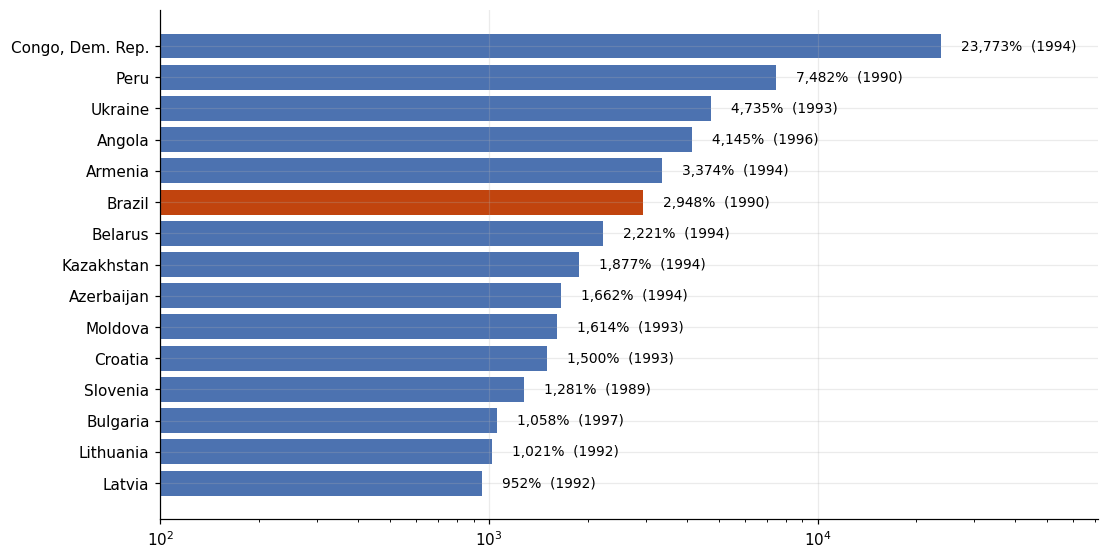

In [209]:
# Maiores picos históricos de inflação 
peaks = (
    inflation_long_raw.loc[inflation_long_raw.groupby("Country Name")["Inflation Rate"].idxmax()]
    .sort_values("Inflation Rate", ascending=False)
    .head(15)
    .iloc[::-1]
)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ["#C1440E" if n == "Brazil" else "#4C72B0" for n in peaks["Country Name"]]
bars = ax.barh(peaks["Country Name"], peaks["Inflation Rate"], color=colors)
ax.set_xscale("log")
ax.set_xlim(100, peaks["Inflation Rate"].max() * 3)
for bar, (_, row) in zip(bars, peaks.iterrows()):
    ax.text(bar.get_width() * 1.15, bar.get_y() + bar.get_height() / 2,
            f"{row['Inflation Rate']:,.0f}%  ({int(row['Year'])})",
            va="center", fontsize=9)
ax.set_title(f"Os 15 maiores picos anuais de inflação ao consumidor ({Y0}–{Y1})", loc="left",
             fontweight="bold")
ax.set_xlabel("Inflação no ano de pico (%, escala log)")
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

print(peaks.iloc[::-1][["Country Name", "Year", "Inflation Rate"]].to_string(index=False))

## Quais países passaram por inflação mais brusca ou elevada?